<a href="https://colab.research.google.com/github/vignesh-codes/ECE9063-Assignment-1/blob/main/svm-v0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv')
df = df.iloc[:25000]
# Convert the 'date' column to datetime format
# df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['date'] = pd.to_datetime(df['date'])
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Extract useful features from the date
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Add lag features (e.g., sales from the previous day, week, and 12 months ago)
df['lag_1'] = df['sales'].shift(1)  # Previous day's sales
df['lag_7'] = df['sales'].shift(7)  # Previous week's sales
df['lag_365'] = df['sales'].shift(365)  # Previous year's sales (seasonality)

# Add rolling mean (7-day and 30-day rolling averages)
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_mean_30'] = df['sales'].rolling(window=30).mean()

# Drop any rows with missing values (due to lag and rolling operations)
df = df.dropna()

In [11]:
from sklearn.preprocessing import StandardScaler
# 2. Define the Features and Target
X = df[['month', 'lag_1', 'lag_7', 'lag_365', 'rolling_mean_7', 'rolling_mean_30']]
y = df['sales']

# Store the indices of the original DataFrame
indices = df.index

# Standardize the features since SVR is sensitive to feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    X_scaled, y, indices, test_size=0.2, random_state=42
)

# Extract the corresponding dates for X_test
test_dates = df.loc[test_indices, 'date']

print(test_dates)

20379   2013-10-21
9963    2015-04-14
24118   2014-01-16
12765   2017-12-15
2327    2014-05-17
           ...    
1702    2017-08-30
2845    2015-10-17
23724   2017-12-18
23924   2013-07-06
24307   2014-07-24
Name: date, Length: 4927, dtype: datetime64[ns]


In [4]:
from sklearn.svm import SVR

# 3. Train the SVR Model
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)  # You can tune C, gamma, and epsilon for better performance
svr.fit(X_train, y_train)

SVR(C=100, gamma=0.1)

In [5]:
# 4. Make Predictions
y_pred = svr.predict(X_test)

# 5. Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared (R2): {r2}')


Mean Absolute Error (MAE): 4.82276629912413
R-squared (R2): 0.9184533950613256


In [10]:
print(X_test)

[[ 1.01413072  1.26960084  0.64707453  1.67897924  1.36521777  1.43148144]
 [-0.7251759  -0.77957509 -0.51180038 -0.89379622 -0.63671096 -0.7519765 ]
 [-1.59482921  0.06682367  0.60250242 -0.26188646  0.20585164  0.28580075]
 ...
 [ 1.5938996   1.44779005  0.42421397  1.58870641  1.08885724  1.47432546]
 [ 0.14447741  1.53688466  1.58308888  2.76225312  1.53373029  1.3759429 ]
 [ 0.14447741  1.35869545  2.42995901  1.31788794  1.93141983  1.94402281]]


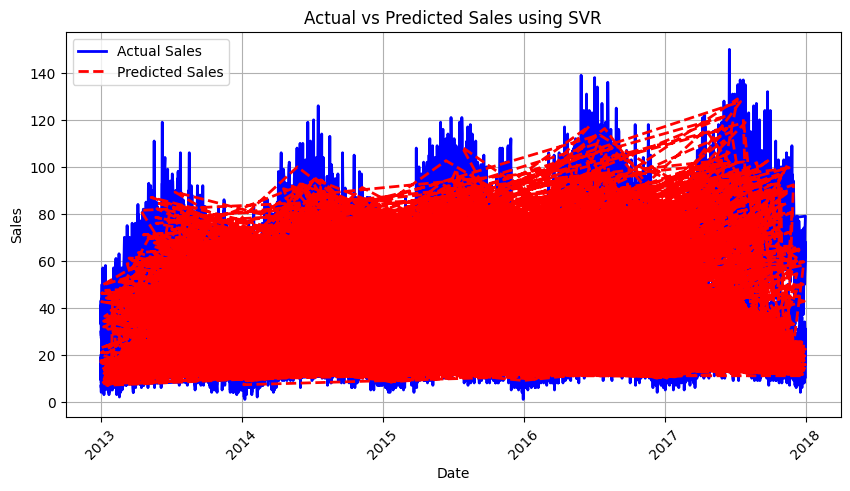

In [13]:
# 6. Visualization
# Extract the corresponding dates for X_test
test_dates = df.loc[test_indices, 'date']

# Plot the actual vs predicted sales
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['sales'], label='Actual Sales', color='blue', linewidth=2)  # Actual sales data
plt.plot(test_dates, y_pred, label='Predicted Sales', color='red', linestyle='--', linewidth=2)  # Predicted sales
plt.title('Actual vs Predicted Sales using SVR')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.show()